In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler

mkdir -p failed for path /shome/users/david_a/.config/matplotlib: [Errno 13] Permission denied: '/shome/users/david_a'
Matplotlib created a temporary cache directory at /tmp/matplotlib-13ld_bmm because there was an issue with the default path (/shome/users/david_a/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
 # Prepare DataFrame
SVR_df = pd.read_csv("../data/SVR_df.csv", parse_dates=["datetime"])

SVR_df.set_index("datetime", inplace=True)

# split train and test
train = SVR_df.loc[:"2021-12-31"]
test = SVR_df.loc["2022-01-01":]

X_train = train.drop("nodal_demand", axis=1)
y_train = train["nodal_demand"]

X_test = test.drop("nodal_demand", axis=1)
y_test = test["nodal_demand"]

scaler_X = StandardScaler()
scaler_y = StandardScaler()

# X_train_scaled = scaler_X.fit_transform(X_train)
# X_test_scaled = scaler_X.transform(X_test)

# X_train_scaled = scaler_X.fit_transform(X_train)
# X_test_scaled = scaler_X.transform(X_test)

# y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()



In [3]:

# Lade das DataFrame mit den Vorhersagen
df_pred = pd.read_csv("../data/svr_predictions_v2.csv")

# Invers skalieren
median_inv = df_pred["median_prediction"]
lower_inv = df_pred["lower_bound"]
upper_inv = df_pred["upper_bound"]


In [9]:
lower_inv

0        2602.406776
1        2411.194402
2        2274.424143
3        2174.219625
4        2125.740229
            ...     
17515    3427.659465
17516    3354.891846
17517    3280.629253
17518    3208.710508
17519    3143.939234
Name: lower_bound, Length: 17520, dtype: float64

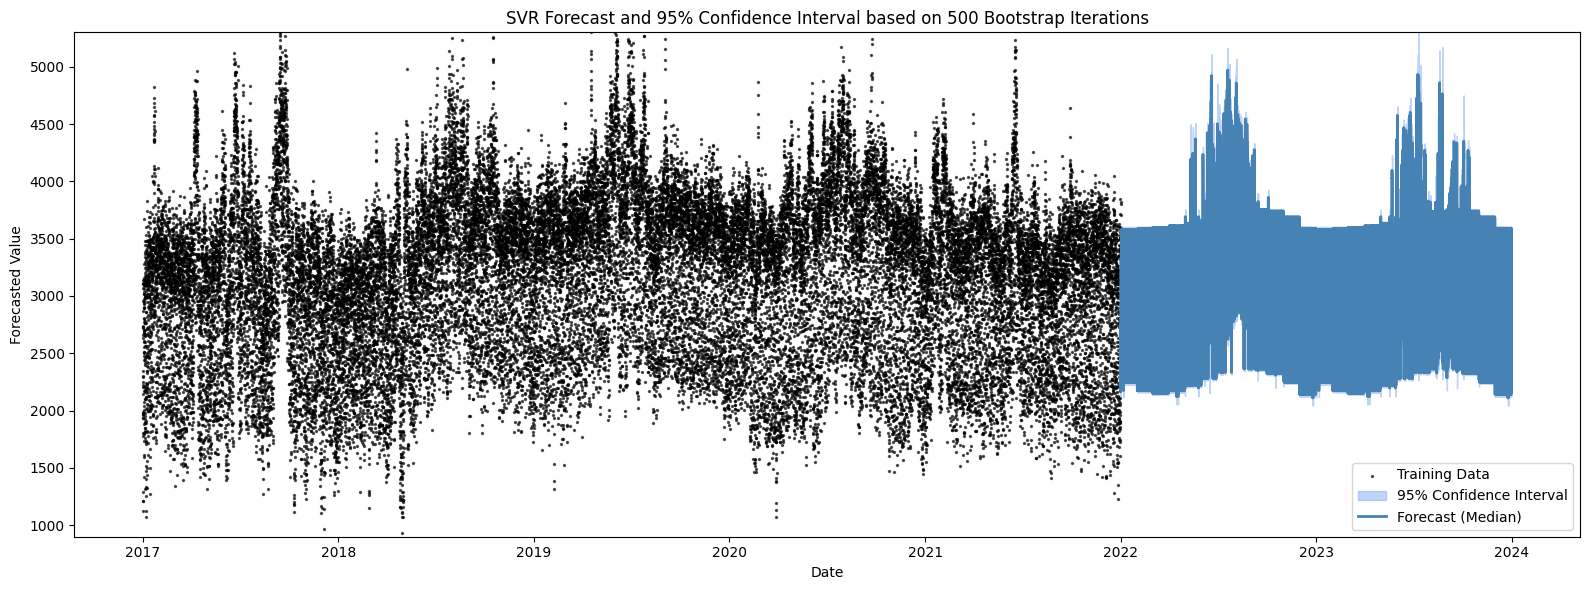

In [12]:

# Erstelle neuen DataFrame mit Datetime-Index aus Testdaten
df_plot = pd.DataFrame({
    "ds": X_test.index,
    "yhat": median_inv,
    "yhat_lower": lower_inv,
    "yhat_upper": upper_inv
})
df_plot.set_index("ds", inplace=True)

import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))
plt.ylim(900, 5300)

# Originale Trainingsdaten als Punkte
plt.scatter(X_train.index, y_train, s=2, color="black", alpha=0.6, label="Training Data")

# Unsicherheitsbereich (95% Konfidenzintervall)
plt.fill_between(df_plot.index, df_plot["yhat_lower"], df_plot["yhat_upper"],
                 color="cornflowerblue", alpha=0.4, label="95% Confidence Interval")

# Zentrale Vorhersage
plt.plot(df_plot.index, df_plot["yhat"], color="steelblue", linewidth=2, label="Forecast (Median)")

plt.title("SVR Forecast and 95% Confidence Interval based on 500 Bootstrap Iterations")
plt.xlabel("Date")
plt.ylabel("Forecasted Value")
plt.legend()
plt.tight_layout()
plt.show()

